### Take a 5x6 NumPy array and plot the histogram of the array with proper labels (without built in histogram function). Show both histograms side by side in a subplot with a title. Show input NumPy array into an image.

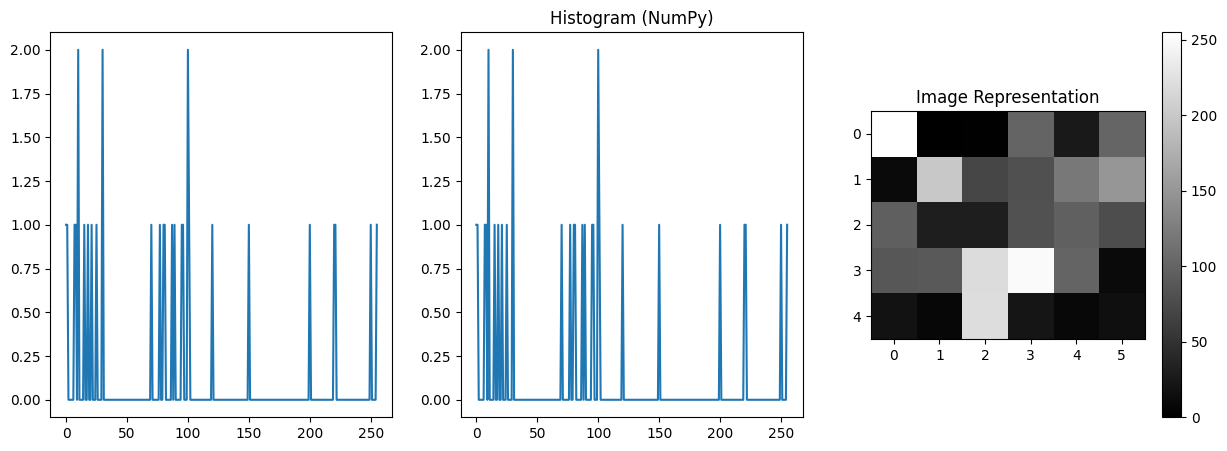

In [18]:
import numpy as np

import matplotlib.pyplot as plt

array = np.array([
    [255,0,1,100,25,101],
    [10,200,70,80,120,150],
    [95,30,30,81,96,77],
    [87,89,220,250,100,10],
    [18,7,221,21,8,15]
])

hist = np.zeros(256)

for i in range(array.shape[0]):
    for j in range(array.shape[1]):
        hist[array[i,j]]+=1

hist2,bins = np.histogram(array,256,[0,256])

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(hist)

plt.subplot(1,3,2)
plt.title("Histogram (NumPy)")
plt.plot(hist2)

plt.subplot(1,3,3)
plt.title("Image Representation")
plt.imshow(array, cmap='gray')
plt.colorbar()

plt.show()

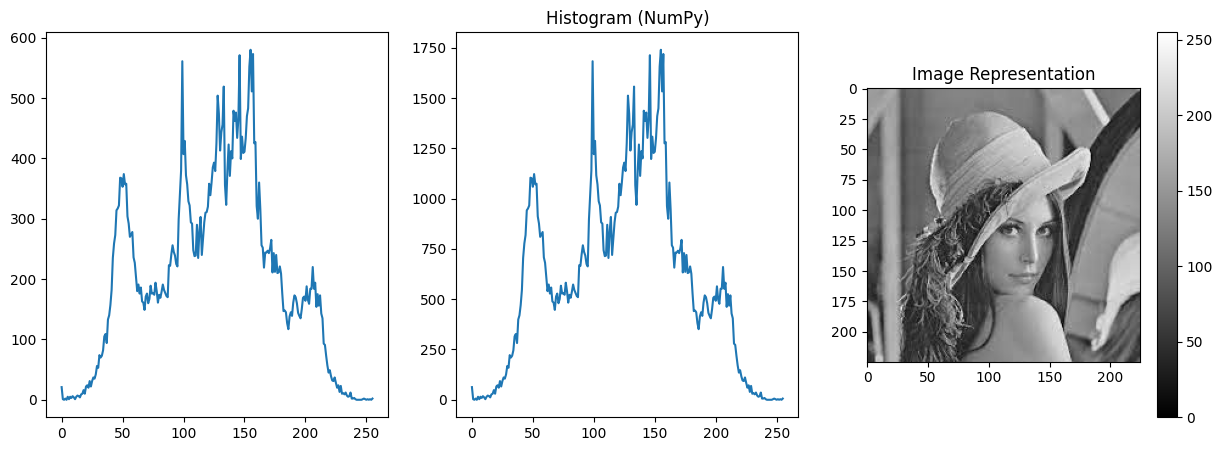

In [19]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

array = cv2.imread("./a.jpg")
hist = np.zeros(256)

for i in range(array.shape[0]):
    for j in range(array.shape[1]):
        hist[array[i,j]]+=1

hist2,bins = np.histogram(array,256,[0,256])

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(hist)

plt.subplot(1,3,2)
plt.title("Histogram (NumPy)")
plt.plot(hist2)

plt.subplot(1,3,3)
plt.title("Image Representation")
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.show()


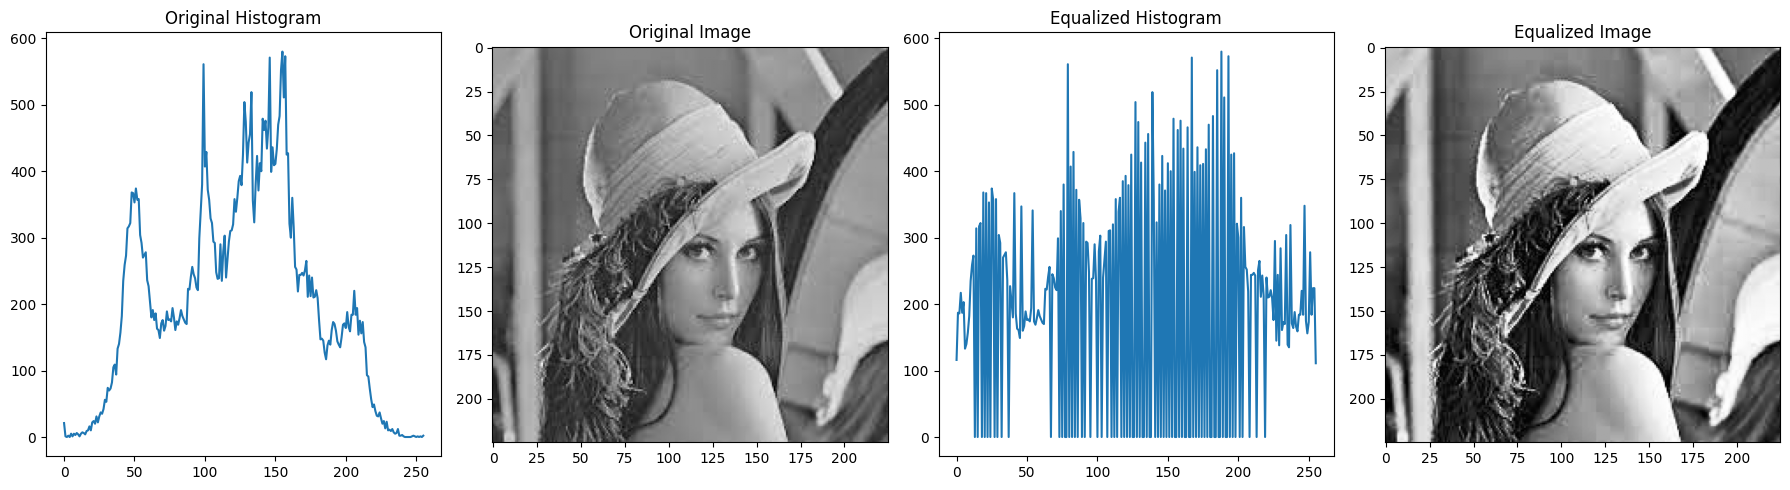

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

array = cv2.imread("./a.jpg", 0)

hist = np.zeros(256)
for i in range(array.shape[0]):
    for j in range(array.shape[1]):
        hist[array[i, j]] += 1

hist2, bins = np.histogram(array.flatten(), 256, [0, 256])

equalized = cv2.equalizeHist(array)

hist_eq, bins_eq = np.histogram(equalized.flatten(), 256, [0, 256])

# Plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.title("Original Histogram")
plt.plot(hist)

plt.subplot(1, 4, 2)
plt.title("Original Image")
plt.imshow(array, cmap='gray')

plt.subplot(1, 4, 3)
plt.title("Equalized Histogram")
plt.plot(hist_eq)

plt.subplot(1, 4, 4)
plt.title("Equalized Image")
plt.imshow(equalized, cmap='gray')

plt.tight_layout()
plt.show()

     Old       PDF       CDF  New
0      0  0.000415  0.000415    0
1      1  0.000020  0.000435    0
2      2  0.000000  0.000435    0
3      3  0.000040  0.000474    0
4      4  0.000000  0.000474    0
5      5  0.000099  0.000573    0
6      6  0.000020  0.000593    0
7      7  0.000099  0.000691    0
8      8  0.000059  0.000751    0
9      9  0.000119  0.000869    0
10    10  0.000079  0.000948    0
11    11  0.000020  0.000968    0
12    12  0.000099  0.001067    0
13    13  0.000138  0.001205    0
14    14  0.000119  0.001323    0
15    15  0.000079  0.001402    0
16    16  0.000178  0.001580    0
17    17  0.000198  0.001778    0
18    18  0.000316  0.002094    1
19    19  0.000198  0.002291    1
20    20  0.000435  0.002726    1
21    21  0.000474  0.003200    1
22    22  0.000395  0.003595    1
23    23  0.000612  0.004207    1
24    24  0.000435  0.004642    1
25    25  0.000612  0.005254    1
26    26  0.000731  0.005985    2
27    27  0.000691  0.006677    2
28    28  0.00

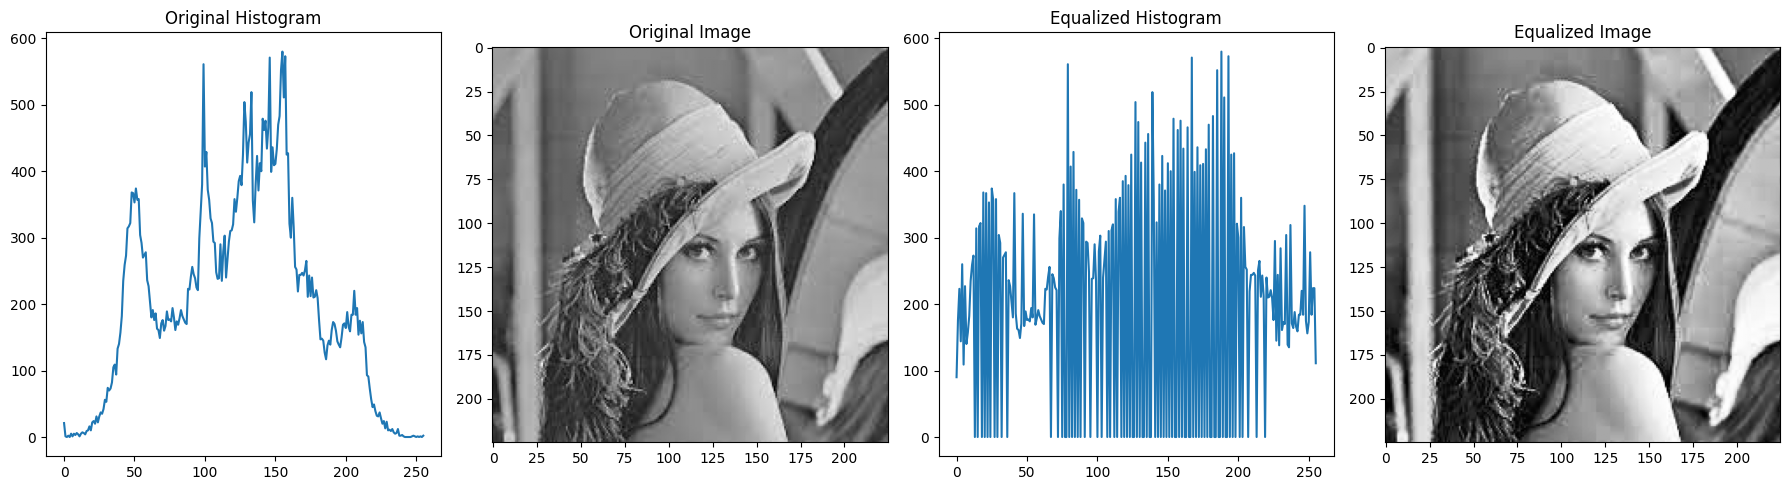

In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./a.jpg", 0)

#  Histogram
hist = np.zeros(256)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i, j]] += 1

# PDF (normalize histogram)
num_pixels = img.shape[0] * img.shape[1]
pdf = hist / num_pixels

# CDF (cumulative sum)
cdf = np.zeros(256)
cdf[0] = pdf[0]
for i in range(1, 256):
    cdf[i] = cdf[i-1] + pdf[i]

# Normalize CDF → [0,255]
cdf_normalized = np.round(cdf * 255).astype(np.uint8)

# Map old pixels → new pixels
equalized = np.zeros_like(img)1
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized[i, j] = cdf_normalized[img[i, j]]

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized[img[i, j]] += 1
# Histograms for comparison


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

table = pd.DataFrame({
    "Old": np.arange(256),
    "PDF": pdf,
    "CDF": cdf,
    "New": cdf_normalized
})

print(table)


# Plot
plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.title("Original Histogram")
plt.plot(hist)

plt.subplot(1,4,2)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(1,4,3)
plt.title("Equalized Histogram")
plt.plot(hist_eq)

plt.subplot(1,4,4)
plt.title("Equalized Image")
plt.imshow(equalized, cmap='gray')

plt.tight_layout()
plt.show()


===== SOURCE TABLE =====
     Gray  Hist_S     PDF_S     CDF_S
0       0    21.0  0.000415  0.000415
1       1     1.0  0.000020  0.000435
2       2     0.0  0.000000  0.000435
3       3     2.0  0.000040  0.000474
4       4     0.0  0.000000  0.000474
5       5     5.0  0.000099  0.000573
6       6     1.0  0.000020  0.000593
7       7     5.0  0.000099  0.000691
8       8     3.0  0.000059  0.000751
9       9     6.0  0.000119  0.000869
10     10     4.0  0.000079  0.000948
11     11     1.0  0.000020  0.000968
12     12     5.0  0.000099  0.001067
13     13     7.0  0.000138  0.001205
14     14     6.0  0.000119  0.001323
15     15     4.0  0.000079  0.001402
16     16     9.0  0.000178  0.001580
17     17    10.0  0.000198  0.001778
18     18    16.0  0.000316  0.002094
19     19    10.0  0.000198  0.002291
20     20    22.0  0.000435  0.002726
21     21    24.0  0.000474  0.003200
22     22    20.0  0.000395  0.003595
23     23    31.0  0.000612  0.004207
24     24    22.0  0.000

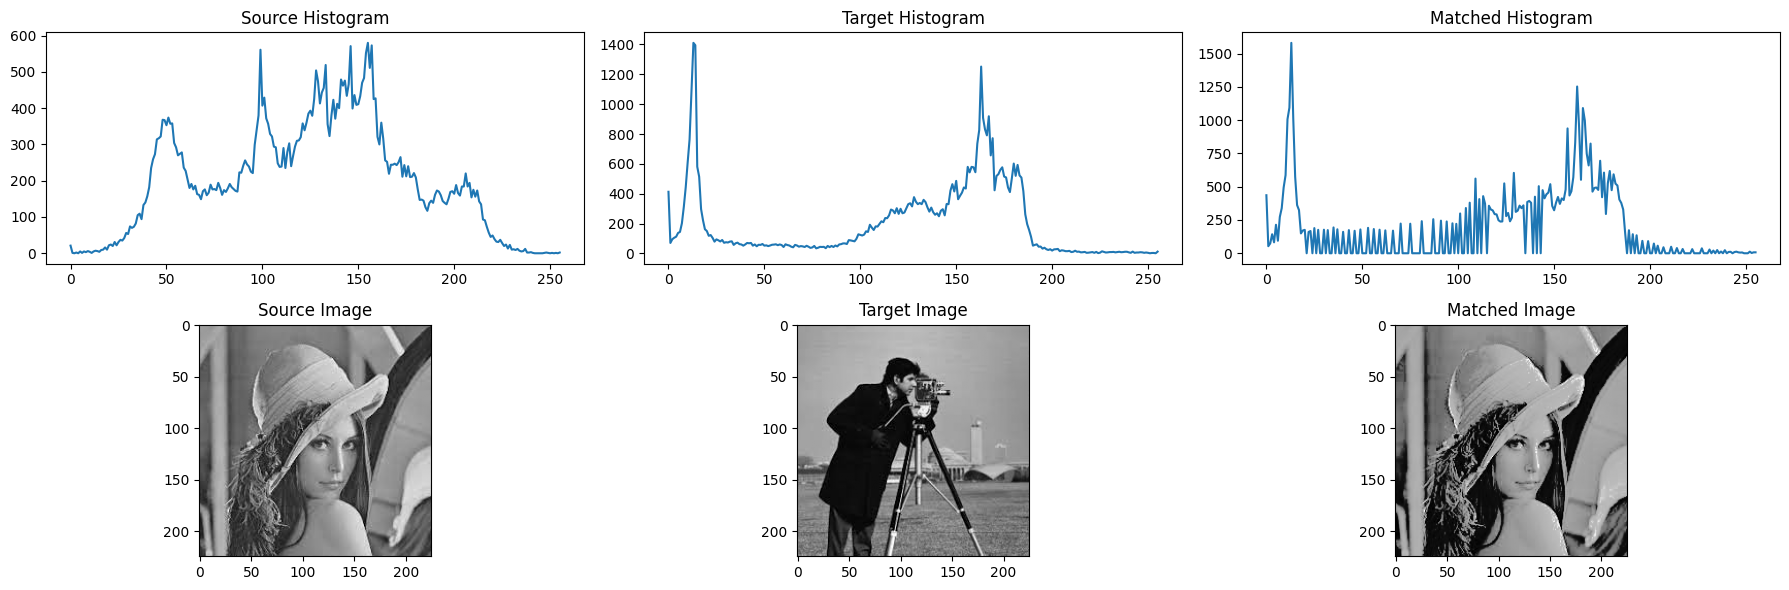

In [22]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale)
src = cv2.imread("./a.jpg", 0)
target = cv2.imread("./ref_image.jpg", 0)   # Target image

def compute_hist_pdf_cdf(image):
    hist = np.zeros(256)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i, j]] += 1

    num_pixels = image.shape[0] * image.shape[1]
    pdf = hist / num_pixels

    cdf = np.zeros(256)
    cdf[0] = pdf[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + pdf[i]

    return hist, pdf, cdf

# Source stats
hist_s, pdf_s, cdf_s = compute_hist_pdf_cdf(src)

# Target stats
hist_t, pdf_t, cdf_t = compute_hist_pdf_cdf(target)

mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    diff = np.abs(cdf_s[i] - cdf_t)
    mapping[i] = np.argmin(diff)

matched = np.zeros_like(src)

for i in range(src.shape[0]):
    for j in range(src.shape[1]):
        matched[i, j] = mapping[src[i, j]]

# Histogram of matched image
hist_m, _, _ = compute_hist_pdf_cdf(matched)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Source table
table_source = pd.DataFrame({
    "Gray": np.arange(256),
    "Hist_S": hist_s,
    "PDF_S": pdf_s,
    "CDF_S": cdf_s
})

# Target table
table_target = pd.DataFrame({
    "Gray": np.arange(256),
    "Hist_T": hist_t,
    "PDF_T": pdf_t,
    "CDF_T": cdf_t
})

# Mapping table
table_mapping = pd.DataFrame({
    "Source Gray": np.arange(256),
    "Mapped Gray": mapping
})

print("\n===== SOURCE TABLE =====")
print(table_source)

print("\n===== TARGET TABLE =====")
print(table_target)

print("\n===== MAPPING TABLE =====")
print(table_mapping)

plt.figure(figsize=(18,6))

plt.subplot(2,3,1)
plt.title("Source Histogram")
plt.plot(hist_s)

plt.subplot(2,3,2)
plt.title("Target Histogram")
plt.plot(hist_t)

plt.subplot(2,3,3)
plt.title("Matched Histogram")
plt.plot(hist_m)

plt.subplot(2,3,4)
plt.title("Source Image")
plt.imshow(src, cmap='gray')

plt.subplot(2,3,5)
plt.title("Target Image")
plt.imshow(target, cmap='gray')

plt.subplot(2,3,6)
plt.title("Matched Image")
plt.imshow(matched, cmap='gray')

plt.tight_layout()
plt.show()


===== SOURCE CALCULATION =====
     Gray_r  Count_nk    PDF_Pr       CDF  Eq_sk
0         0      21.0  0.000415  0.000415      0
1         1       1.0  0.000020  0.000435      0
2         2       0.0  0.000000  0.000435      0
3         3       2.0  0.000040  0.000474      0
4         4       0.0  0.000000  0.000474      0
5         5       5.0  0.000099  0.000573      0
6         6       1.0  0.000020  0.000593      0
7         7       5.0  0.000099  0.000691      0
8         8       3.0  0.000059  0.000751      0
9         9       6.0  0.000119  0.000869      0
10       10       4.0  0.000079  0.000948      0
11       11       1.0  0.000020  0.000968      0
12       12       5.0  0.000099  0.001067      0
13       13       7.0  0.000138  0.001205      0
14       14       6.0  0.000119  0.001323      0
15       15       4.0  0.000079  0.001402      0
16       16       9.0  0.000178  0.001580      0
17       17      10.0  0.000198  0.001778      0
18       18      16.0  0.000316  0.00

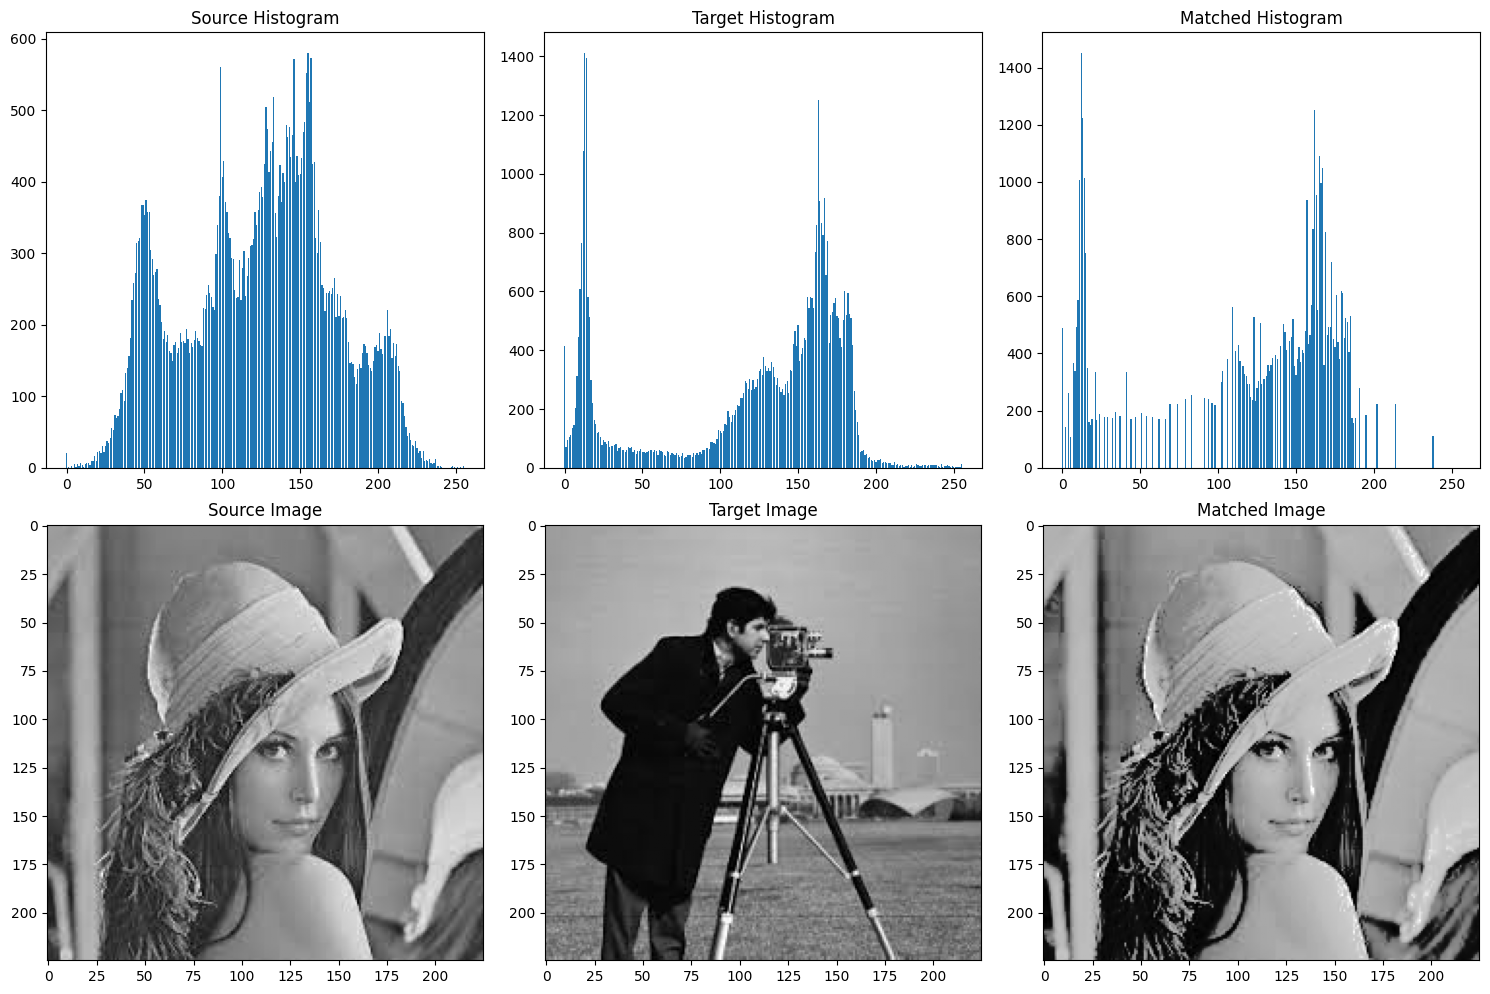

In [31]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load images (grayscale)
src = cv2.imread("./a.jpg", 0)
target = cv2.imread("./ref_image.jpg", 0)

def manual_histogram_processing(image):
    #  Compute Histogram (n_k)
    hist = np.zeros(256)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            hist[image[i, j]] += 1

    #  Compute PDF (p_r = n_k / MN)
    num_pixels = image.shape[0] * image.shape[1]
    pdf = hist / num_pixels

    #  Compute CDF (Sum of PDF)
    cdf = np.cumsum(pdf)
    
    # Histogram Equalization Scaling (s = (L-1) * CDF)
    # We round to the nearest integer as per manual calculation rules in the PDF
    equalized_values = np.round(cdf * 255).astype(np.uint8)

    return hist, pdf, cdf, equalized_values

# --- Process Source Image ---
hist_s, pdf_s, cdf_s, s_k = manual_histogram_processing(src)

# --- Process Target Image ---
hist_t, pdf_t, cdf_t, v_q = manual_histogram_processing(target)

# --- Mapping (Inverse Transformation) ---
# We find z such that G(z) is closest to T(r)
mapping = np.zeros(256, dtype=np.uint8)

for i in range(256):
    # Casting to float prevents the unsigned integer wrap-around
    s_val = float(s_k[i]) 
    min_diff = float('inf')
    best_index = 0
    
    for q in range(256):
        v_val = float(v_q[q])
        current_diff = abs(s_val - v_val)
        
        if current_diff < min_diff:
            min_diff = current_diff
            best_index = q
            
    mapping[i] = best_index

# --- Apply Mapping to Create Matched Image ---
matched = mapping[src]

# Calculate final histogram for verification
hist_m, _, _, _ = manual_histogram_processing(matched)


table_source = pd.DataFrame({
    "Gray_r": np.arange(256),
    "Count_nk": hist_s,
    "PDF_Pr": pdf_s,
    "CDF": cdf_s,
    "Eq_sk": s_k
})

table_target = pd.DataFrame({
    "Gray_z": np.arange(256),
    "Count_nk": hist_t,
    "PDF_Pz": pdf_t,
    "CDF": cdf_t,
    "Eq_vq": v_q
})

mapping_summary = pd.DataFrame({
    "Source_Gray": np.arange(256),
    "Mapped_to_Target": mapping
})

pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Auto width
pd.set_option('display.max_colwidth', None)  # Full column content

print("\n===== SOURCE CALCULATION =====")
print(table_source)

print("\n===== TARGET CALCULATION =====")
print(table_target)

print("\n===== FINAL MAPPING =====")
print(mapping_summary)

# --- VISUALIZATION ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1); plt.title("Source Histogram"); plt.bar(range(256), hist_s)
plt.subplot(2, 3, 2); plt.title("Target Histogram"); plt.bar(range(256), hist_t)
plt.subplot(2, 3, 3); plt.title("Matched Histogram"); plt.bar(range(256), hist_m)

plt.subplot(2, 3, 4); plt.title("Source Image"); plt.imshow(src, cmap='gray')
plt.subplot(2, 3, 5); plt.title("Target Image"); plt.imshow(target, cmap='gray')
plt.subplot(2, 3, 6); plt.title("Matched Image"); plt.imshow(matched, cmap='gray')

plt.tight_layout()
plt.show()